# Intron motif enrichment workflow

This notebook performs a focused test: do motifs from a selected MEME list show significant presence in a selected set of introns (`fishis`)?

- Use the `parnet_clean` kernel.
- The null model is an exact mononucleotide-preserving shuffle within each intron.
- Each intron is tested against its own matched null distribution, then motif-level significance is evaluated across the full `fishis` intron collection.


In [1]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
MODULE_PATH = REPO_ROOT / "resubmission" / "scripts" / "intron_motif_enrichment.py"

spec = importlib.util.spec_from_file_location("intron_motif_enrichment", MODULE_PATH)
ime = importlib.util.module_from_spec(spec)
assert spec.loader is not None
sys.modules[spec.name] = ime
spec.loader.exec_module(ime)

PARNET_PYTHON = Path("/lustre/groups/crna01/projects/collabs/shared/cenvs/parnet_clean/bin/python")
print(f"Kernel python: {sys.executable}")
print(f"Expected parnet_clean python: {PARNET_PYTHON}")
print(f"Support module: {MODULE_PATH}")

plt.rcParams["figure.dpi"] = 120


Kernel python: /ictstr01/groups/crna01/projects/collabs/shared/cenvs/parnet_clean/bin/python3.10
Expected parnet_clean python: /lustre/groups/crna01/projects/collabs/shared/cenvs/parnet_clean/bin/python
Support module: /ictstr01/groups/crna01/projects/collabs/gabi/resubmission/scripts/intron_motif_enrichment.py


## 1. Configure the run

Set the transcript or gene of interest, pick the motifs to test, and choose null-model settings.


In [5]:
# TERT I11  HsaINT1044026
# FANCA I5 HsaINT1013334
# CENPT I11 HsaINT0033466
# BRD8 I9 HsaINT0018536
# METTL3 I8 (HsaINT0102211) & I9 (HsaINT1022852)
# RAD52 I10 HsaINT0136677
fishis = ['HsaINT1044026', 'HsaINT1013334', 'HsaINT0033466', 'HsaINT0018536', 'HsaINT0102211', 'HsaINT1022852', 'HsaINT0136677']
fishis_labels = {
    'HsaINT1044026': 'TERT I11',
    'HsaINT1013334': 'FANCA I5',
    'HsaINT0033466': 'CENPT I11',
    'HsaINT0018536': 'BRD8 I9',
    'HsaINT0102211': 'METTL3 I8',
    'HsaINT1022852': 'METTL3 I9',
    'HsaINT0136677': 'RAD52 I10'
}

In [6]:
FASTA_PATH = REPO_ROOT / "resubmission" / "data" / "introns_50fks.fasta"
METADATA_PATH = REPO_ROOT / "resubmission" / "data" / "metadata_selected.csv"
MEME_PATH = REPO_ROOT / "resubmission" / "data" / "external" / "pwms_all_motifs_ids.meme"
OUTPUT_DIR = REPO_ROOT / "resubmission" / "results" / "intron_motif_enrichment"

SEQ_ID_COL = "EVENT"
FASTA_ID_FUNC = lambda x: x.split("_")[0]

# Primary target set for this notebook: selected introns to test.
TARGET_INTRONS = list(fishis)

MOTIF_NAMES = [
    "RBM4_M00072_2.00",
    "RBM4_M00131_2.00",
    "RBM4_M00636_2.00",
    "RBM4_M00637_2.00",
    "RBM4_M00638_2.00",
    "RBM4_M00795_2.00",
]

NULL_MODE = "shuffle"
N_NULL = 1000
THRESHOLD_SAMPLES = 50_000
WINDOW_FPR = 0.01
PAIRWISE_STAT = "hit_count"
RANDOM_SEED = 42


## 2. Load motifs and intron sequences

This cell parses the MEME file and joins FASTA sequences to metadata.
Then it keeps only the introns listed in `TARGET_INTRONS` (the `fishis` set).


In [7]:
motifs = ime.parse_meme_minimal(MEME_PATH)
sequence_table = ime.build_sequence_table(
    fasta_path=FASTA_PATH,
    metadata_path=METADATA_PATH,
    seq_id_col=SEQ_ID_COL,
    fasta_id_func=FASTA_ID_FUNC,
)

target_set = {str(x) for x in TARGET_INTRONS}
sequence_table[SEQ_ID_COL] = sequence_table[SEQ_ID_COL].astype(str)
selected = sequence_table[sequence_table[SEQ_ID_COL].isin(target_set)].copy()

missing_targets = sorted(target_set - set(selected[SEQ_ID_COL].astype(str)))

print(f"Loaded {len(motifs):,} motifs from {MEME_PATH.name}")
print(f"Requested {len(target_set)} target introns")
print(f"Recovered {len(selected)} target introns from FASTA+metadata")
if missing_targets:
    print(f"Missing {len(missing_targets)} target introns:", missing_targets)

selected[[col for col in [SEQ_ID_COL, 'GENE', 'Intron_Position', 'sequence_length', 'gc_content'] if col in selected.columns]]

Loaded 467 motifs from pwms_all_motifs_ids.meme
Requested 7 target introns
Recovered 7 target introns from FASTA+metadata


,EVENT,GENE,Intron_Position,sequence_length,gc_content
29386,HsaINT1013334,FANCA,5.0,2438,0.478671
40922,HsaINT0102211,METTL3,8.0,219,0.470320
43441,HsaINT0018536,BRD8,9.0,1305,0.402299
46514,HsaINT1022852,METTL3,9.0,267,0.393258
48872,HsaINT0136677,RAD52,10.0,408,0.431373
50464,HsaINT0033466,CENPT,11.0,400,0.577500
52931,HsaINT1044026,TERT,11.0,3902,0.528703


## 3. Inspect the motifs being tested

A quick sanity check before scanning.


In [10]:
pd.DataFrame(
    {
        'motif': MOTIF_NAMES,
        'width': [motifs[name].width for name in MOTIF_NAMES],
        'background_A': [motifs[name].background[0] for name in MOTIF_NAMES],
        'background_C': [motifs[name].background[1] for name in MOTIF_NAMES],
        'background_G': [motifs[name].background[2] for name in MOTIF_NAMES],
        'background_T': [motifs[name].background[3] for name in MOTIF_NAMES],
    }
)


,motif,width,background_A,background_C,background_G,background_T
0,RBM4_M00072_2.00,7,0.25,0.25,0.25,0.25
1,RBM4_M00131_2.00,7,0.25,0.25,0.25,0.25
2,RBM4_M00636_2.00,7,0.25,0.25,0.25,0.25
3,RBM4_M00637_2.00,21,0.25,0.25,0.25,0.25
4,RBM4_M00638_2.00,20,0.25,0.25,0.25,0.25
5,RBM4_M00795_2.00,6,0.25,0.25,0.25,0.25


## 4. Build the transcript-level background and score thresholds

Thresholds are estimated from random motif-width windows drawn from the pooled base composition of the selected introns.


In [11]:
encoded_map = {
    str(row[SEQ_ID_COL]): ime.encode_sequence(str(row['sequence']))
    for _, row in selected.iterrows()
}
pooled_encoded = np.concatenate([encoded for encoded in encoded_map.values() if encoded.size > 0])
pooled_background = ime.base_frequencies_from_encoded(pooled_encoded)

rng = np.random.default_rng(RANDOM_SEED)
threshold_rows = []
thresholds = {}
for motif_name in MOTIF_NAMES:
    motif = motifs[motif_name]
    threshold = ime.estimate_hit_threshold(
        motif=motif,
        background=pooled_background,
        rng=np.random.default_rng(rng.integers(0, 2**32 - 1)),
        n_samples=THRESHOLD_SAMPLES,
        window_fpr=WINDOW_FPR,
    )
    thresholds[motif_name] = threshold
    threshold_rows.append({
        'motif': motif_name,
        'width': motif.width,
        'score_threshold': threshold,
        'window_fpr': WINDOW_FPR,
    })

print('Pooled background frequencies (A, C, G, T):', pooled_background.round(4))
thresholds_df = pd.DataFrame(threshold_rows)
thresholds_df


Pooled background frequencies (A, C, G, T): [0.2432 0.2303 0.2585 0.2679]


,motif,width,score_threshold,window_fpr
0,RBM4_M00072_2.00,7,3.507278,0.01
1,RBM4_M00131_2.00,7,3.949018,0.01
2,RBM4_M00636_2.00,7,4.852861,0.01
3,RBM4_M00637_2.00,21,-13.602772,0.01
4,RBM4_M00638_2.00,20,-32.915629,0.01
5,RBM4_M00795_2.00,6,4.757404,0.01


## 5. Scan the observed introns

This stage calculates observed hit counts, max motif scores, and hit locations for each intron-motif pair.


In [12]:
observed_rows = []
hit_rows = []

for _, row in selected.iterrows():
    seq_id = str(row[SEQ_ID_COL])
    encoded = encoded_map[seq_id]
    for motif_name in MOTIF_NAMES:
        motif = motifs[motif_name]
        fwd_log_odds, rev_log_odds = ime.motif_to_log_odds(motif, background=motif.background)
        observed = ime.scan_encoded_sequence(
            encoded=encoded,
            fwd_log_odds=fwd_log_odds,
            rev_log_odds=rev_log_odds,
            threshold=thresholds[motif_name],
        )

        rec = {
            'motif': motif_name,
            SEQ_ID_COL: seq_id,
            'sequence_length': int(encoded.size),
            'window_count': observed['window_count'],
            'hit_count': observed['hit_count'],
            'hit_density': observed['hit_density'],
            'max_score': observed['max_score'],
        }
        for col in selected.columns:
            if col in rec or col == 'sequence':
                continue
            rec[col] = row[col]
        observed_rows.append(rec)

        scaled_len = max(int(encoded.size - motif.width + 1), 1)
        for pos, score, strand in zip(
            observed['hit_positions'],
            observed['hit_scores'],
            observed['hit_strands'],
        ):
            hit_rows.append({
                'motif': motif_name,
                SEQ_ID_COL: seq_id,
                'position': int(pos),
                'relative_position': float(pos / scaled_len),
                'score': float(score),
                'strand': strand,
            })

observed_df = pd.DataFrame(observed_rows)
hits_df = pd.DataFrame(hit_rows)
observed_df[['motif', SEQ_ID_COL, 'Intron_Position', 'hit_count', 'hit_density', 'max_score']]


,motif,EVENT,Intron_Position,hit_count,hit_density,max_score
0,RBM4_M00072_2.00,HsaINT1013334,5.0,11,0.004523,9.943886
1,RBM4_M00131_2.00,HsaINT1013334,5.0,15,0.006168,8.962852
2,RBM4_M00636_2.00,HsaINT1013334,5.0,35,0.014391,7.507828
3,RBM4_M00637_2.00,HsaINT1013334,5.0,31,0.012821,-2.184271
4,RBM4_M00638_2.00,HsaINT1013334,5.0,18,0.007441,-14.010439
5,RBM4_M00795_2.00,HsaINT1013334,5.0,13,0.005343,9.349308
6,RBM4_M00072_2.00,HsaINT0102211,8.0,0,0.000000,0.208258
7,RBM4_M00131_2.00,HsaINT0102211,8.0,0,0.000000,2.093953
8,RBM4_M00636_2.00,HsaINT0102211,8.0,4,0.018779,8.577655
9,RBM4_M00637_2.00,HsaINT0102211,8.0,1,0.005025,-6.756692


## 6. Simulate matched null distributions

For every intron and motif, generate randomized sequences of the same length and composition, then compute empirical p-values and z-scores.


In [13]:
null_cache = {}
result_rows = []
rng = np.random.default_rng(RANDOM_SEED + 1)

for _, row in observed_df.iterrows():
    motif_name = row['motif']
    seq_id = str(row[SEQ_ID_COL])
    motif = motifs[motif_name]
    encoded = encoded_map[seq_id]

    null_df = ime.simulate_null_distribution(
        encoded=encoded,
        motif=motif,
        threshold=thresholds[motif_name],
        rng=np.random.default_rng(rng.integers(0, 2**32 - 1)),
        n_null=N_NULL,
        null_mode=NULL_MODE,
    )
    null_cache[(motif_name, seq_id)] = null_df

    rec = row.to_dict()
    rec['null_mean_hit_count'] = null_df['hit_count'].mean()
    rec['null_mean_max_score'] = null_df['max_score'].mean()
    rec['hit_count_excess'] = rec['hit_count'] - rec['null_mean_hit_count']
    rec['max_score_excess'] = rec['max_score'] - rec['null_mean_max_score']
    rec['hit_count_pvalue'] = ime.empirical_pvalue(rec['hit_count'], null_df['hit_count'])
    rec['max_score_pvalue'] = ime.empirical_pvalue(rec['max_score'], null_df['max_score'])
    rec['hit_density_pvalue'] = ime.empirical_pvalue(rec['hit_density'], null_df['hit_density'])
    rec['hit_count_z'] = ime.z_from_null(rec['hit_count'], null_df['hit_count'])
    rec['max_score_z'] = ime.z_from_null(rec['max_score'], null_df['max_score'])
    rec['hit_density_z'] = ime.z_from_null(rec['hit_density'], null_df['hit_density'])
    rec['score_threshold'] = thresholds[motif_name]
    rec['null_mode'] = NULL_MODE
    rec['n_null'] = N_NULL
    result_rows.append(rec)

results = pd.DataFrame(result_rows)
results['hit_count_qvalue'] = ime.benjamini_hochberg(results['hit_count_pvalue'])
results['max_score_qvalue'] = ime.benjamini_hochberg(results['max_score_pvalue'])
results['hit_density_qvalue'] = ime.benjamini_hochberg(results['hit_density_pvalue'])
results = results.sort_values(['motif', 'Intron_Position', SEQ_ID_COL]).reset_index(drop=True)

results[[
    'motif', SEQ_ID_COL, 'Intron_Position', 'hit_count', 'null_mean_hit_count',
    'hit_count_z', 'hit_count_pvalue', 'hit_count_qvalue',
    'max_score', 'max_score_z', 'max_score_pvalue', 'max_score_qvalue',
]]


,motif,EVENT,Intron_Position,hit_count,null_mean_hit_count,hit_count_z,hit_count_pvalue,hit_count_qvalue,max_score,max_score_z,max_score_pvalue,max_score_qvalue
0,RBM4_M00072_2.00,HsaINT1013334,5.0,11,20.926,-1.704491,0.977023,1.0,9.943886,0.083922,0.546454,1.000000
1,RBM4_M00072_2.00,HsaINT0102211,8.0,0,1.476,-1.031016,1.000000,1.0,0.208258,-1.815599,0.973027,1.000000
2,RBM4_M00072_2.00,HsaINT0018536,9.0,0,4.613,-1.707988,1.000000,1.0,2.826335,-2.071518,0.985015,1.000000
3,RBM4_M00072_2.00,HsaINT1022852,9.0,0,0.749,-0.726445,1.000000,1.0,-2.380637,-2.105937,0.996004,1.000000
4,RBM4_M00072_2.00,HsaINT0136677,10.0,0,1.924,-1.083815,1.000000,1.0,1.490289,-1.595762,0.966034,1.000000
5,RBM4_M00072_2.00,HsaINT0033466,11.0,0,9.131,-2.521168,1.000000,1.0,0.208258,-4.700864,1.000000,1.000000
6,RBM4_M00072_2.00,HsaINT1044026,11.0,12,57.126,-4.655975,1.000000,1.0,6.776071,-4.337182,1.000000,1.000000
7,RBM4_M00131_2.00,HsaINT1013334,5.0,15,21.679,-1.021719,0.865135,1.0,8.962852,-0.440081,0.714286,1.000000
8,RBM4_M00131_2.00,HsaINT0102211,8.0,0,1.606,-0.950376,1.000000,1.0,2.093953,-1.277000,0.899101,1.000000
9,RBM4_M00131_2.00,HsaINT0018536,9.0,0,4.223,-1.478579,1.000000,1.0,2.061115,-2.502437,0.998002,1.000000


## 7. Inspect one null distribution directly

Use this cell to see how one intron-motif pair compares to its matched background.


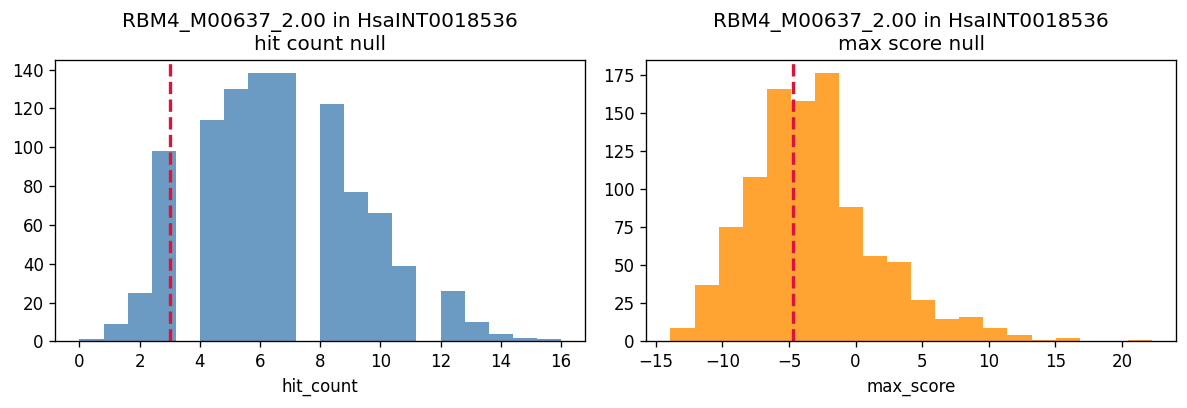

In [14]:
EXAMPLE_MOTIF = 'RBM4_M00637_2.00' #MOTIF_NAMES[0]
EXAMPLE_INTRON = 'HsaINT0018536' #str(selected.iloc[0][SEQ_ID_COL])
example_null = null_cache[(EXAMPLE_MOTIF, EXAMPLE_INTRON)]
example_obs = results.query('motif == @EXAMPLE_MOTIF and EVENT == @EXAMPLE_INTRON').iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(example_null['hit_count'], bins=20, color='steelblue', alpha=0.8)
axes[0].axvline(example_obs['hit_count'], color='crimson', linestyle='--', linewidth=2)
axes[0].set_title(f'{EXAMPLE_MOTIF} in {EXAMPLE_INTRON}\nhit count null')
axes[0].set_xlabel('hit_count')

axes[1].hist(example_null['max_score'], bins=20, color='darkorange', alpha=0.8)
axes[1].axvline(example_obs['max_score'], color='crimson', linestyle='--', linewidth=2)
axes[1].set_title(f'{EXAMPLE_MOTIF} in {EXAMPLE_INTRON}\nmax score null')
axes[1].set_xlabel('max_score')

plt.tight_layout()
plt.show()


## 8. Compare introns directly

This uses the matched null distributions to ask whether one intron is significantly stronger than another for the chosen statistic.


In [ ]:
pairwise = ime.pairwise_intron_comparisons(
    results=results,
    null_distributions=null_cache,
    seq_id_col=SEQ_ID_COL,
    stat=PAIRWISE_STAT,
)
pairwise

## 9. Plot the results

The heatmap summarizes per-intron enrichment, and the hit-position plots show where motif matches occur inside each intron.


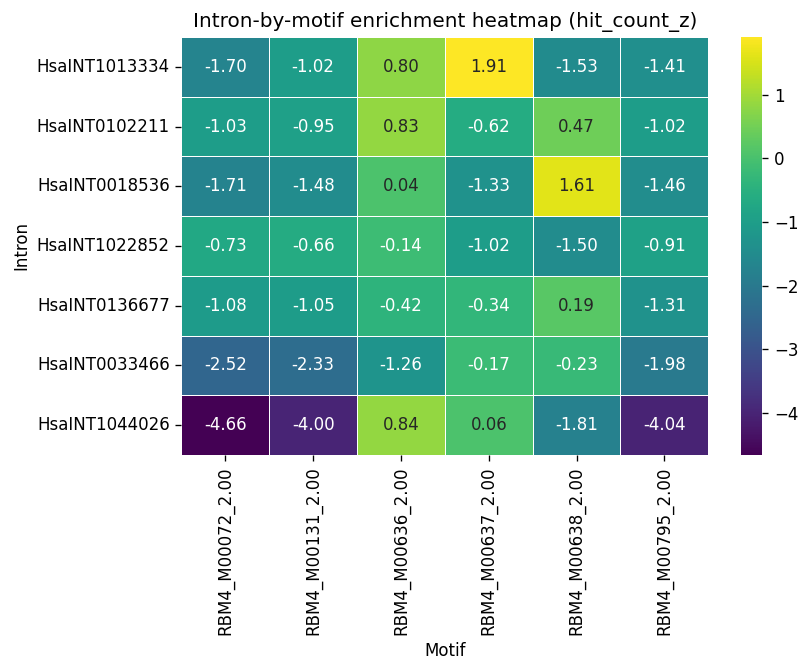

In [36]:
fig = ime.plot_enrichment_heatmap(results, seq_id_col=SEQ_ID_COL, value_col='hit_count_z')
#display(fig)
#plt.show()

In [17]:
MOTIF_NAMES

['RBM4_M00072_2.00',
 'RBM4_M00131_2.00',
 'RBM4_M00636_2.00',
 'RBM4_M00637_2.00',
 'RBM4_M00638_2.00',
 'RBM4_M00795_2.00']

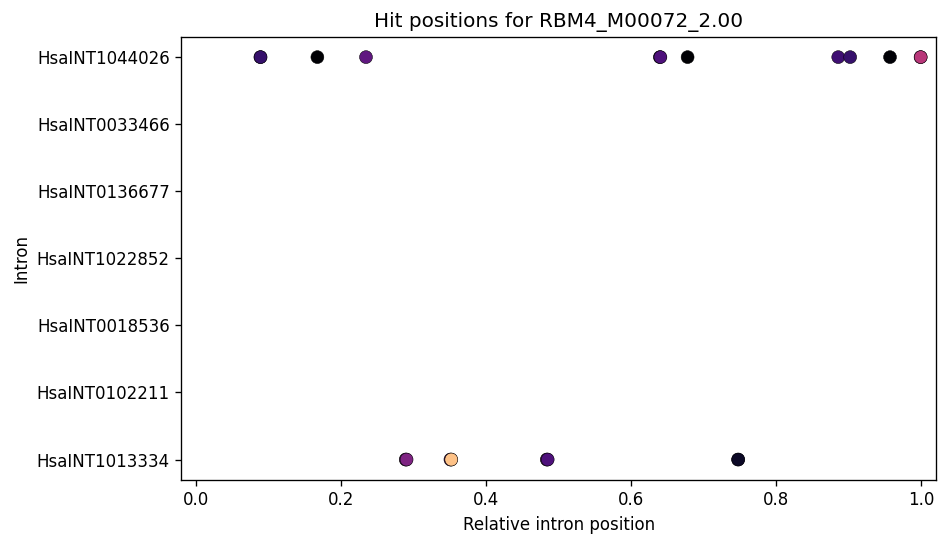

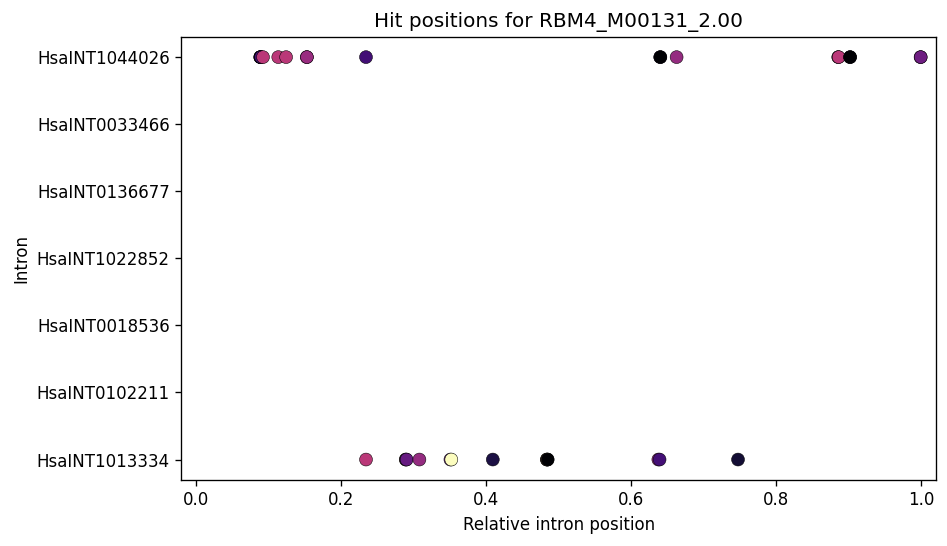

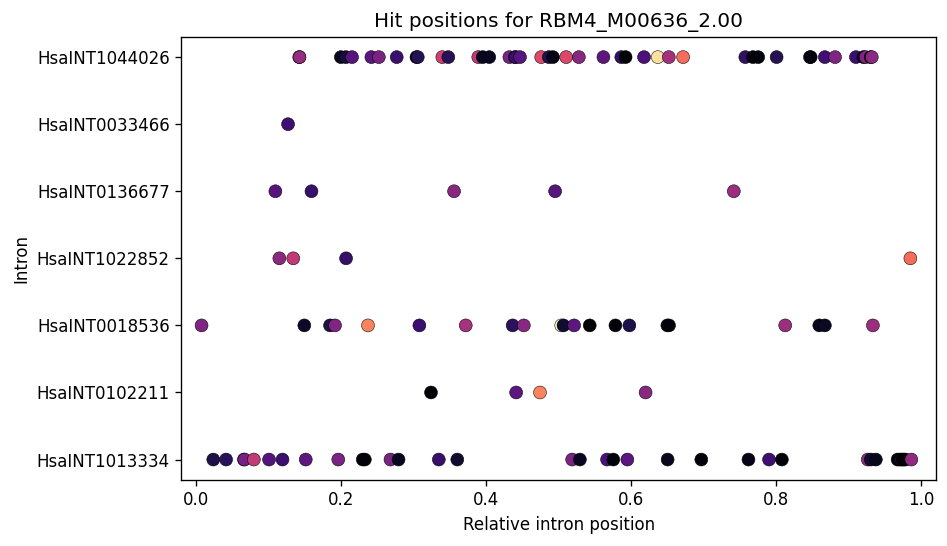

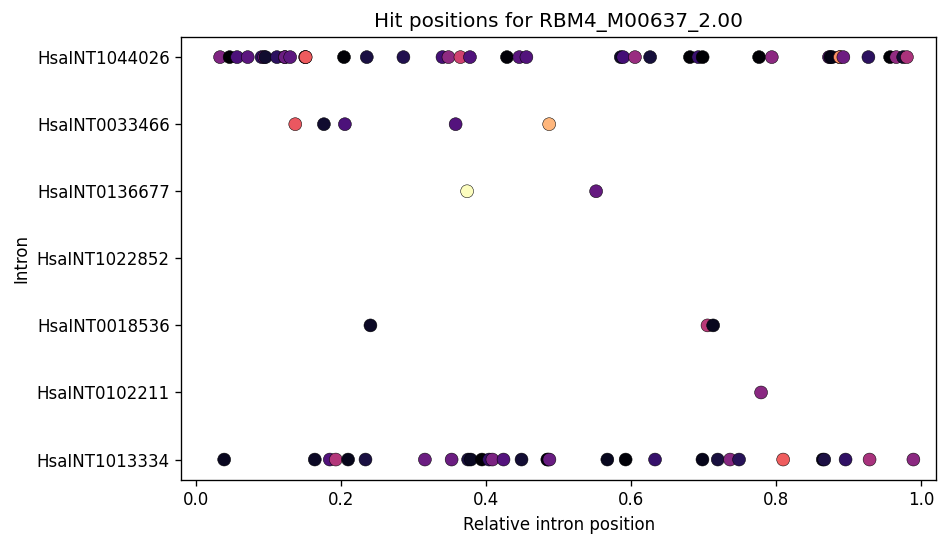

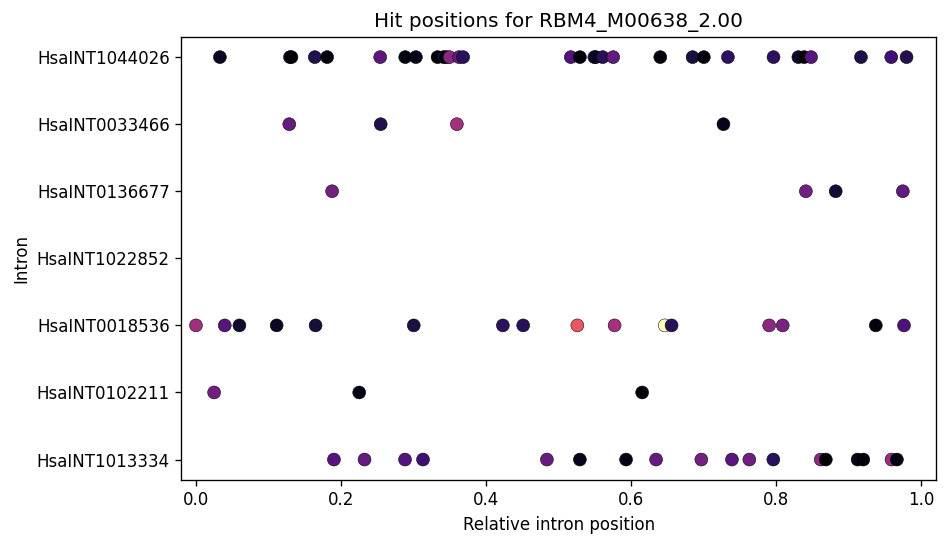

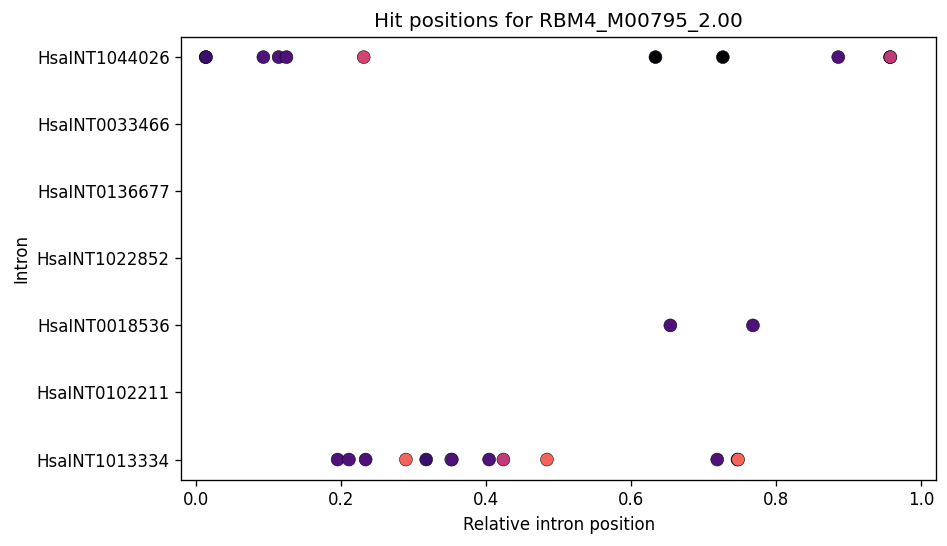

In [23]:
for mtf in MOTIF_NAMES:
    fig = ime.plot_hit_positions(hits_df, selected, mtf, seq_id_col=SEQ_ID_COL)

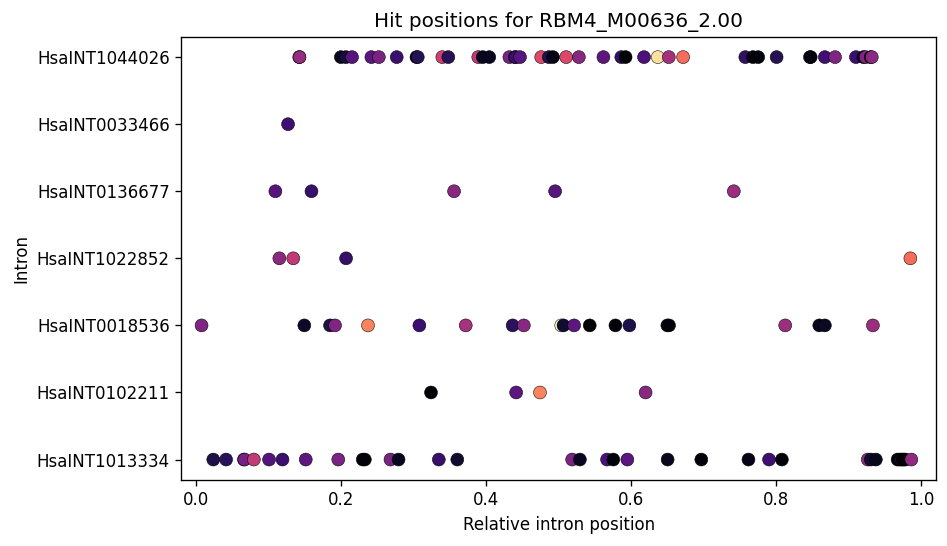

In [21]:
# for motif_name in MOTIF_NAMES:
#     fig = ime.plot_hit_positions(hits_df, selected, motif_name, seq_id_col=SEQ_ID_COL)
#     if fig is not None:
#         display(fig)
#         plt.show()
fig = ime.plot_hit_positions(hits_df, selected, 'RBM4_M00636_2.00', seq_id_col=SEQ_ID_COL)

## 10. Per-intron motif enrichment vs. length-matched background

This section tests, **for each intron individually**, whether its motif score is higher than expected given a length-matched background of introns.

**Design:**
- Sample `N_BACKGROUND` introns from the full dataset (excluding the target set) whose lengths fall within `[min_target / LENGTH_MATCH_FACTOR, max_target × LENGTH_MATCH_FACTOR]`.
- Scan those background introns with the same motifs and thresholds.
- For each (intron × motif) pair: compute an empirical p-value as the rank of the observed score within the background distribution (one-sided, upper tail).
- BH-correct across all (intron × motif) tests.

`TARGET_INTRONS` drives the test — edit it in the config cell to use any intron set.


In [38]:
# Background-comparison settings
N_BACKGROUND = 1000        # background introns to sample (length-matched)
LENGTH_MATCH_FACTOR = 2.0  # window: [min_target/factor, max_target*factor]
BG_STAT = "hit_count"      # statistic for the per-intron comparison

print(f"Background sample: {N_BACKGROUND} introns")
print(f"Length window factor: ×{LENGTH_MATCH_FACTOR}")
print(f"Test statistic: {BG_STAT}")


Background sample: 1000 introns
Length window factor: ×2.0
Test statistic: hit_count


In [39]:
# Sample length-matched background introns from the full sequence table (excluding fishis)
fishis_set = {str(x) for x in fishis}
bg_pool = sequence_table[~sequence_table[SEQ_ID_COL].astype(str).isin(fishis_set)].copy()
bg_pool[SEQ_ID_COL] = bg_pool[SEQ_ID_COL].astype(str)

fishis_lengths = selected["sequence_length"].values
len_min = float(fishis_lengths.min()) / LENGTH_MATCH_FACTOR
len_max = float(fishis_lengths.max()) * LENGTH_MATCH_FACTOR

bg_pool = bg_pool[bg_pool["sequence_length"].between(len_min, len_max)].copy()

rng_bg = np.random.default_rng(RANDOM_SEED + 100)
n_sample = min(N_BACKGROUND, len(bg_pool))
if n_sample < N_BACKGROUND:
    print(f"Warning: only {len(bg_pool)} background candidates available after length filter.")
bg_sample = bg_pool.sample(n=n_sample, random_state=int(rng_bg.integers(0, 2**32 - 1))).reset_index(drop=True)

print(f"Fishis lengths: min={fishis_lengths.min():.0f} bp, max={fishis_lengths.max():.0f} bp")
print(f"Background window: [{len_min:.0f}, {len_max:.0f}] bp → {len(bg_pool):,} candidates")
print(f"Background sample size: {n_sample}")
bg_sample[[col for col in [SEQ_ID_COL, "GENE", "sequence_length", "gc_content"] if col in bg_sample.columns]].head(10)


Fishis lengths: min=219 bp, max=3902 bp
Background window: [110, 7804] bp → 71,719 candidates
Background sample size: 1000


,EVENT,GENE,sequence_length,gc_content
0,HsaINT0040123,COPS6,751,0.471372
1,HsaINT0065240,FMR1,185,0.329730
2,HsaINT0101464,MED13L,2865,0.349389
3,HsaINT0172950,TRPC1,356,0.280899
4,HsaINT0124961,PIK3C2B,588,0.498299
5,HsaINT1042993,SSBP3,191,0.534031
6,HsaINT0180885,VPS45,4105,0.376614
7,HsaINT0152414,SLC30A5,3164,0.362832
8,HsaINT0186959,ZNF34,559,0.626118
9,HsaINT0080999,INPP5E,592,0.667230


In [41]:
# Encode background sequences and scan with each motif (same thresholds as fishis scan)
bg_encoded_map = {
    str(row[SEQ_ID_COL]): ime.encode_sequence(str(row["sequence"]))
    for _, row in bg_sample.iterrows()
}

bg_scan_rows = []
for _, row in bg_sample.iterrows():
    seq_id = str(row[SEQ_ID_COL])
    encoded = bg_encoded_map[seq_id]
    for motif_name in MOTIF_NAMES:
        motif = motifs[motif_name]
        fwd_log_odds, rev_log_odds = ime.motif_to_log_odds(motif, background=motif.background)
        obs = ime.scan_encoded_sequence(
            encoded=encoded,
            fwd_log_odds=fwd_log_odds,
            rev_log_odds=rev_log_odds,
            threshold=thresholds[motif_name],
        )
        bg_scan_rows.append({
            "motif": motif_name,
            SEQ_ID_COL: seq_id,
            "sequence_length": int(encoded.size),
            "hit_count": obs["hit_count"],
            "hit_density": obs["hit_density"],
            "max_score": obs["max_score"],
        })

bg_scan = pd.DataFrame(bg_scan_rows)

# Quick background hit-rate summary
bg_summary = (
    bg_scan
    .assign(is_present=lambda d: d[BG_STAT] >= 1)
    .groupby("motif")
    .agg(n_bg=(SEQ_ID_COL, "count"), n_bg_present=("is_present", "sum"))
    .assign(bg_fraction_present=lambda d: d["n_bg_present"] / d["n_bg"])
    .reset_index()
)
print("Background hit rates:")
display(bg_summary)


Background hit rates:


,motif,n_bg,n_bg_present,bg_fraction_present
0,RBM4_M00072_2.00,1000,698,0.698
1,RBM4_M00131_2.00,1000,706,0.706
2,RBM4_M00636_2.00,1000,972,0.972
3,RBM4_M00637_2.00,1000,932,0.932
4,RBM4_M00638_2.00,1000,967,0.967
5,RBM4_M00795_2.00,1000,702,0.702


In [42]:
# Per-intron empirical test against the length-matched background distribution
per_intron_rows = []
target_ids = sorted(results[SEQ_ID_COL].astype(str).unique())

for motif_name in MOTIF_NAMES:
    bg_vals = bg_scan[bg_scan["motif"] == motif_name][BG_STAT].to_numpy()
    bg_mean = float(bg_vals.mean())
    bg_sd = float(bg_vals.std(ddof=1)) if len(bg_vals) > 1 else np.nan

    for seq_id in target_ids:
        row = results[(results["motif"] == motif_name) & (results[SEQ_ID_COL].astype(str) == seq_id)]
        if row.empty:
            continue
        obs = float(row.iloc[0][BG_STAT])
        # One-sided upper-tail empirical p-value
        p_val = (1 + int(np.sum(bg_vals >= obs))) / (len(bg_vals) + 1)
        z = (obs - bg_mean) / bg_sd if bg_sd and np.isfinite(bg_sd) and bg_sd > 0 else np.nan
        per_intron_rows.append({
            "motif": motif_name,
            SEQ_ID_COL: seq_id,
            "label": fishis_labels.get(seq_id, seq_id),
            f"obs_{BG_STAT}": obs,
            "bg_mean": bg_mean,
            "bg_sd": bg_sd,
            "bg_n": int(len(bg_vals)),
            "z_vs_background": z,
            "pvalue_vs_background": p_val,
        })

per_intron_test = pd.DataFrame(per_intron_rows)
if not per_intron_test.empty:
    per_intron_test["qvalue_vs_background"] = ime.benjamini_hochberg(per_intron_test["pvalue_vs_background"])
else:
    per_intron_test["qvalue_vs_background"] = np.nan

per_intron_test.sort_values("pvalue_vs_background").reset_index(drop=True)


,motif,EVENT,label,obs_hit_count,bg_mean,bg_sd,bg_n,z_vs_background,pvalue_vs_background,qvalue_vs_background
0,RBM4_M00637_2.00,HsaINT1044026,TERT I11,44.0,11.140,13.739256,1000,2.391687,0.029970,0.643357
1,RBM4_M00637_2.00,HsaINT1013334,FANCA I5,31.0,11.140,13.739256,1000,1.445493,0.070929,0.643357
2,RBM4_M00795_2.00,HsaINT1013334,FANCA I5,13.0,3.732,5.257358,1000,1.762863,0.071928,0.643357
3,RBM4_M00131_2.00,HsaINT1044026,TERT I11,19.0,6.708,11.303385,1000,1.087462,0.086913,0.643357
4,RBM4_M00795_2.00,HsaINT1044026,TERT I11,11.0,3.732,5.257358,1000,1.382443,0.096903,0.643357
5,RBM4_M00072_2.00,HsaINT1044026,TERT I11,12.0,4.972,8.439102,1000,0.832790,0.123876,0.643357
6,RBM4_M00638_2.00,HsaINT1044026,TERT I11,31.0,14.389,14.676617,1000,1.131800,0.128871,0.643357
7,RBM4_M00131_2.00,HsaINT1013334,FANCA I5,15.0,6.708,11.303385,1000,0.733586,0.129870,0.643357
8,RBM4_M00072_2.00,HsaINT1013334,FANCA I5,11.0,4.972,8.439102,1000,0.714294,0.137862,0.643357
9,RBM4_M00636_2.00,HsaINT1044026,TERT I11,44.0,26.972,30.390307,1000,0.560310,0.227772,0.956643


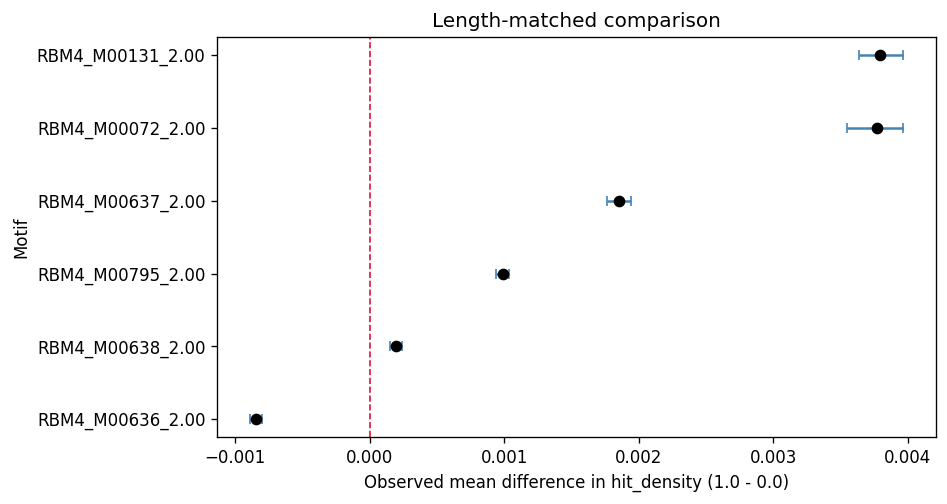

In [ ]:
if per_intron_test.empty:
    print("No results to plot.")
else:
    # Pivot z-scores into intron × motif matrix
    pivot_z = per_intron_test.pivot(index="label", columns="motif", values="z_vs_background")
    pivot_p = per_intron_test.pivot(index="label", columns="motif", values="pvalue_vs_background")
    pivot_q = per_intron_test.pivot(index="label", columns="motif", values="qvalue_vs_background")

    fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(MOTIF_NAMES)), max(3, 0.55 * len(target_ids) + 1)))
    im = ax.imshow(pivot_z.values, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
    plt.colorbar(im, ax=ax, label=f"z-score vs. background ({BG_STAT})")

    ax.set_xticks(range(len(pivot_z.columns)))
    ax.set_xticklabels(pivot_z.columns, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(pivot_z.index)))
    ax.set_yticklabels(pivot_z.index, fontsize=9)

    # Annotate each cell with p / q values
    for i, intron_label in enumerate(pivot_z.index):
        for j, motif_name in enumerate(pivot_z.columns):
            p = pivot_p.loc[intron_label, motif_name]
            q = pivot_q.loc[intron_label, motif_name]
            z = pivot_z.loc[intron_label, motif_name]
            sig = "**" if q < 0.05 else ("*" if p < 0.05 else "")
            txt = f"p={p:.2g}\n{sig}" if not np.isnan(z) else "NA"
            ax.text(j, i, txt, ha="center", va="center", fontsize=7,
                    color="white" if abs(z) > 1.5 else "black")

    ax.set_title(f"Per-intron motif enrichment vs. length-matched background (n={len(bg_sample)})\n"
                 f"* p<0.05, ** q<0.05")
    plt.tight_layout()
    plt.show()


## 11. Save the tables

Uncomment and run this cell if you want to write the analysis tables to disk.


In [ ]:
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# prefix = f"fishis_n{len(TARGET_INTRONS)}"
# selected.to_csv(OUTPUT_DIR / f'{prefix}_selected_introns.csv', index=False)
# thresholds_df.to_csv(OUTPUT_DIR / f'{prefix}_thresholds.csv', index=False)
# observed_df.to_csv(OUTPUT_DIR / f'{prefix}_observed_scan.csv', index=False)
# results.to_csv(OUTPUT_DIR / f'{prefix}_results.csv', index=False)
# pairwise.to_csv(OUTPUT_DIR / f'{prefix}_pairwise.csv', index=False)
# hits_df.to_csv(OUTPUT_DIR / f'{prefix}_hits.csv', index=False)
# bg_sample.drop(columns=["sequence"], errors="ignore").to_csv(OUTPUT_DIR / f'{prefix}_bg_sample.csv', index=False)
# bg_scan.to_csv(OUTPUT_DIR / f'{prefix}_bg_scan.csv', index=False)
# per_intron_test.to_csv(OUTPUT_DIR / f'{prefix}_per_intron_bg_test.csv', index=False)
